# Edgelist Network Analysis and Epidemic Modeling

## Introduction

This notebook demonstrates how to work with **real-world network data** loaded from edgelist files in the epidemic modeling workflow.

We will:

- **Load a network from an edgelist file**
- **Integrate it with the existing workflow functions**
- **Analyze network properties** (degree distribution, centrality measures, etc.)
- **Run epidemic simulations** on the real network data
- **Compare with synthetic network types**

This approach allows you to study epidemic dynamics on empirical network structures, such as social networks, contact networks, or transportation networks.

## Setup

First, we'll set up the environment and create necessary directories for storing results.

In [1]:
# Navigate to the directory containing this file
cd(@__DIR__)

# Create directories if they don't exist
if !isdir("data")
    mkdir("data")
end
if !isdir("figures")
    mkdir("figures")
end
if !isdir("output")
    mkdir("output")
end

Next, we activate the current directory as the environment for Pkg and import the required packages. This includes the additional `GraphIO.EdgeList` package for loading edgelist files.

In [2]:
# Import the Pkg module, activate the current directory as the environment for Pkg, instantiate the environment
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

# Import the necessary packages
using Agents, Graphs, Random, Plots, DataFrames, CSV, CategoricalArrays, Statistics, StatsBase, StatsPlots, Distributions, Measures, Optim
using GraphIO.EdgeList, GraphPlot

  Activating project at `c:\Users\leost\julia-workspace\espidam-tutorial-2025`
 project at `c:\Users\leost\julia-workspace\espidam-tutorial-2025`


## Loading Network from Edgelist

We'll load a network from an edgelist file. The edgelist format is a common way to represent networks where each line contains two node IDs representing an edge.

The code below:
1. Loads the graph from the edgelist file
2. Removes any duplicate edges
3. Converts it to an undirected simple graph
4. Visualizes the network structure

In [3]:
# Load graph from edgelist file
graph = loadgraph("degs/network", "graph_key", EdgeListFormat())

# Convert to undirected simple graph, removes all double edges
graph = SimpleGraph(graph)

println("Loaded network with $(nv(graph)) nodes and $(ne(graph)) edges")
println("Mean degree: $(round(2 * ne(graph) / nv(graph), digits=2))")

Loaded network with 52 nodes and 272 edges
Mean degree: 10.46


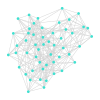

In [4]:
# Visualize the network (if it's not too large)
if nv(graph) <= 200  # Only plot if network is reasonably small
    gplot(graph)
else
    println("Network too large for visualization ($(nv(graph)) nodes)")
    println("Consider using a subset or different visualization approach")
end

## Model Definition

Now we'll set up the epidemic model using the same modular approach as in the other tutorials. The model components are defined in separate source files for modularity and reusability.

In [5]:
include("src/create_graph.jl")

# Agent creation: agents of type Person and properties status, days_infected and risk
@agent struct Person(GraphAgent)
    status::Symbol = :S #((S)usceptible, (I)nfected, (H)ospitalized, (R)ecovered)
    days_infected::Int = 0 # number of days since infection
    risk::Symbol = :high # something to differentiate agents (here, high and low risk)
end

include("src/initialize.jl")
include("src/agent_step.jl")

# Model step: keep track of the infection numbers
function model_step!(model::ABM)
    model.susceptible_count = sum([model[i].status == :S for i in 1:nv(model.graph)])
    model.infected_count = sum([model[i].status == :I for i in 1:nv(model.graph)])
    model.hospitalized_count = sum([model[i].status == :H for i in 1:nv(model.graph)])
    model.recovered_count = sum([model[i].status == :R for i in 1:nv(model.graph)])
end

model_step! (generic function with 1 method)

## Model Initialization with Edgelist Network

There are two ways to initialize the model with the edgelist network:

### Method 1: Using the `custom_graph` parameter
Pass the pre-loaded graph directly to the initialization function.

### Method 2: Using the `:edgelist` network type
Let the initialization function load the edgelist automatically.

We'll demonstrate both approaches:

In [18]:
# Method 1: Use the custom_graph parameter to pass the pre-loaded graph
model = initialize(
    network_type = :custom,  # Will be set automatically when using custom_graph
    custom_graph = graph,
    patient_zero = :random,
    high_risk = :random,
    fraction_high_risk = 0.1,
    trans_prob = 0.1,
    days_to_recovered = 14,
    seed = 42,
    low_risk_factor = 1.0
)

println("Model initialized with $(model.n_nodes) agents")
println("Network type: $(model.network_type)")
println("Mean degree: $(model.mean_degree)")

Model initialized with 52 agents
Network type: custom
Mean degree: 10


In [7]:
# Alternative Method 2: Use the edgelist network type to load directly
# Uncomment the code below to try this approach instead:

# model_alt = initialize(
#     network_type = :edgelist,
#     edgelist_path = "degs/network",
#     patient_zero = :random,
#     high_risk = :random,
#     fraction_high_risk = 0.1,
#     trans_prob = 0.1,
#     days_to_recovered = 14,
#     seed = 42,
#     low_risk_factor = 1.0
# )

# println("Alternative model initialized with $(model_alt.n_nodes) agents")
# println("Network type: $(model_alt.network_type)")
# println("Mean degree: $(model_alt.mean_degree)")

## Network Analysis

Now we can analyze the network structure using the regular workflow functions. This includes calculating various network metrics and centrality measures.

In [11]:
include("src/analyze_graph.jl")
include("src/plotting.jl")

# Analyze the graph
println("Analyzing the edgelist network...")
graph_analysis = analyze_graph(model.graph)

display(graph_analysis["summary"])

display(first(graph_analysis["centrality"], 10))

Row,metric,value
,String,Float64
1,Mean Degree,10.4615
2,Density,0.205128
3,Clustering Coefficient,0.345602
4,Assortativity,-0.0192022
5,Diameter,3.0
6,Number of Connected Components,1.0
7,Max Component Length,52.0


Row,node_id,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality
,Int64,Float64,Float64,Float64,Float64
1,1,0.27451,0.0325305,0.579545,0.19436
2,2,0.215686,0.0250489,0.554348,0.149862
3,3,0.27451,0.0369048,0.573034,0.188956
4,4,0.294118,0.0540435,0.573034,0.18235
5,5,0.235294,0.026656,0.536842,0.135358
6,6,0.117647,0.00454088,0.455357,0.0762131
7,7,0.215686,0.0201639,0.525773,0.144068
8,8,0.254902,0.0292113,0.573034,0.173234
9,9,0.196078,0.0119338,0.515152,0.14449


Analyzing the edgelist network...


In [9]:
# Save the analysis to CSV files
CSV.write("data/graph_summary_$(model.network_type)_mdeg_$(model.mean_degree).csv", graph_analysis["summary"])
CSV.write("data/centrality_$(model.network_type)_mdeg_$(model.mean_degree).csv", graph_analysis["centrality"])

println("Analysis results saved to data/ directory")

Analysis results saved to data/ directory


## Epidemic Simulation

Let's run an epidemic simulation on the edgelist network and visualize the dynamics.

In [19]:
# Run a single simulation to test dynamics
println("Running SIHR epidemic simulation...")
adata = [:status]
mdata = [:susceptible_count, :infected_count, :hospitalized_count, :recovered_count]
adf, mdf = run!(model, 100; adata, mdata)

println("Simulation completed!")
println("Final outbreak size: $(mdf[end, :recovered_count]) out of $(model.n_nodes) agents")
println("Peak hospitalized: $(maximum(mdf.hospitalized_count)) agents")
println("Attack rate: $(round(100 * mdf[end, :recovered_count] / model.n_nodes, digits=1))%")

Running SIHR epidemic simulation...
Simulation completed!
Final outbreak size: 52 out of 52 agents
Peak hospitalized: 7 agents
Attack rate: 100.0%


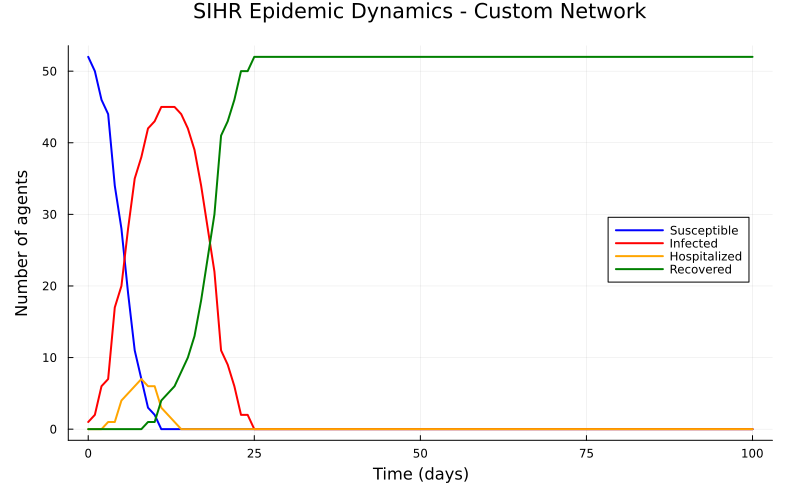

Dynamics plot saved to figures/ directory


In [20]:
# Plot the epidemic dynamics
dynamics_plot = plot_epidemic_trajectories(mdf, model.network_type)
display(dynamics_plot)
savefig(dynamics_plot, "figures/dynamics_$(model.network_type)_mdeg_$(model.mean_degree).pdf")

println("Dynamics plot saved to figures/ directory")

## Network Comparison

One of the advantages of integrating edgelist networks into the regular workflow is the ability to compare them with synthetic network types. Let's compare our edgelist network with random and small-world networks.

Analyzing random network...
Analyzing smallworld network...
Analyzing edgelist network...
Saving network metrics comparison plot to figures/network_metrics_comparison_random_smallworld_edgelist_mdeg_10.pdf
Network comparison completed with 52 nodes for all network types!


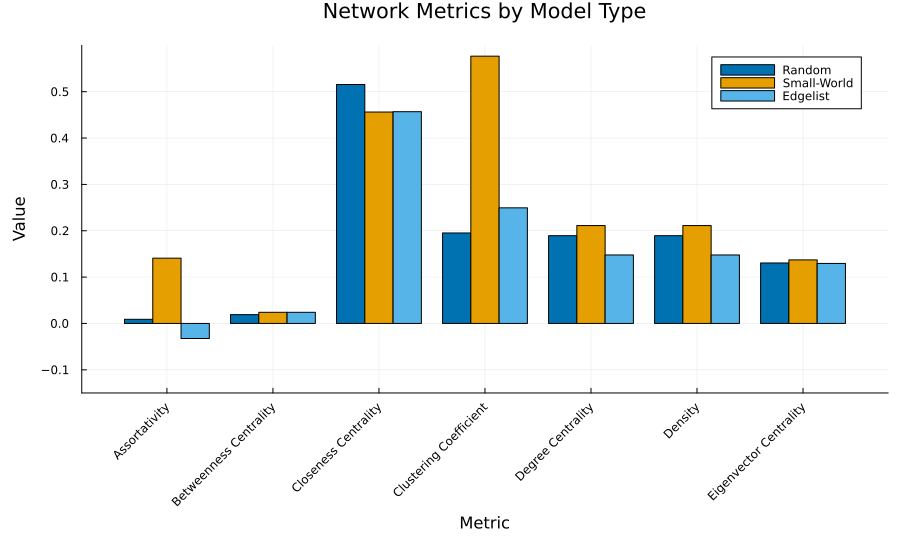

In [12]:
# Compare network metrics across different network types
# Use the same number of nodes as the edgelist network for fair comparison
include("src/plotting.jl")

comparison_plot = plot_network_metrics_comparison(
    network_types=[:random, :smallworld, :edgelist], 
    mean_degree=model.mean_degree, 
    n_nodes=model.n_nodes  # Use actual edgelist network size
)

display(comparison_plot)
println("Network comparison completed with $(model.n_nodes) nodes for all network types!")


Generating centrality comparison for network structure analysis...
Saving combined centrality comparison plot to figures/centrality_comparison_random_smallworld_preferential_edgelist_mdeg_10.pdf
Centrality comparison completed! Results saved to figures/ directory.


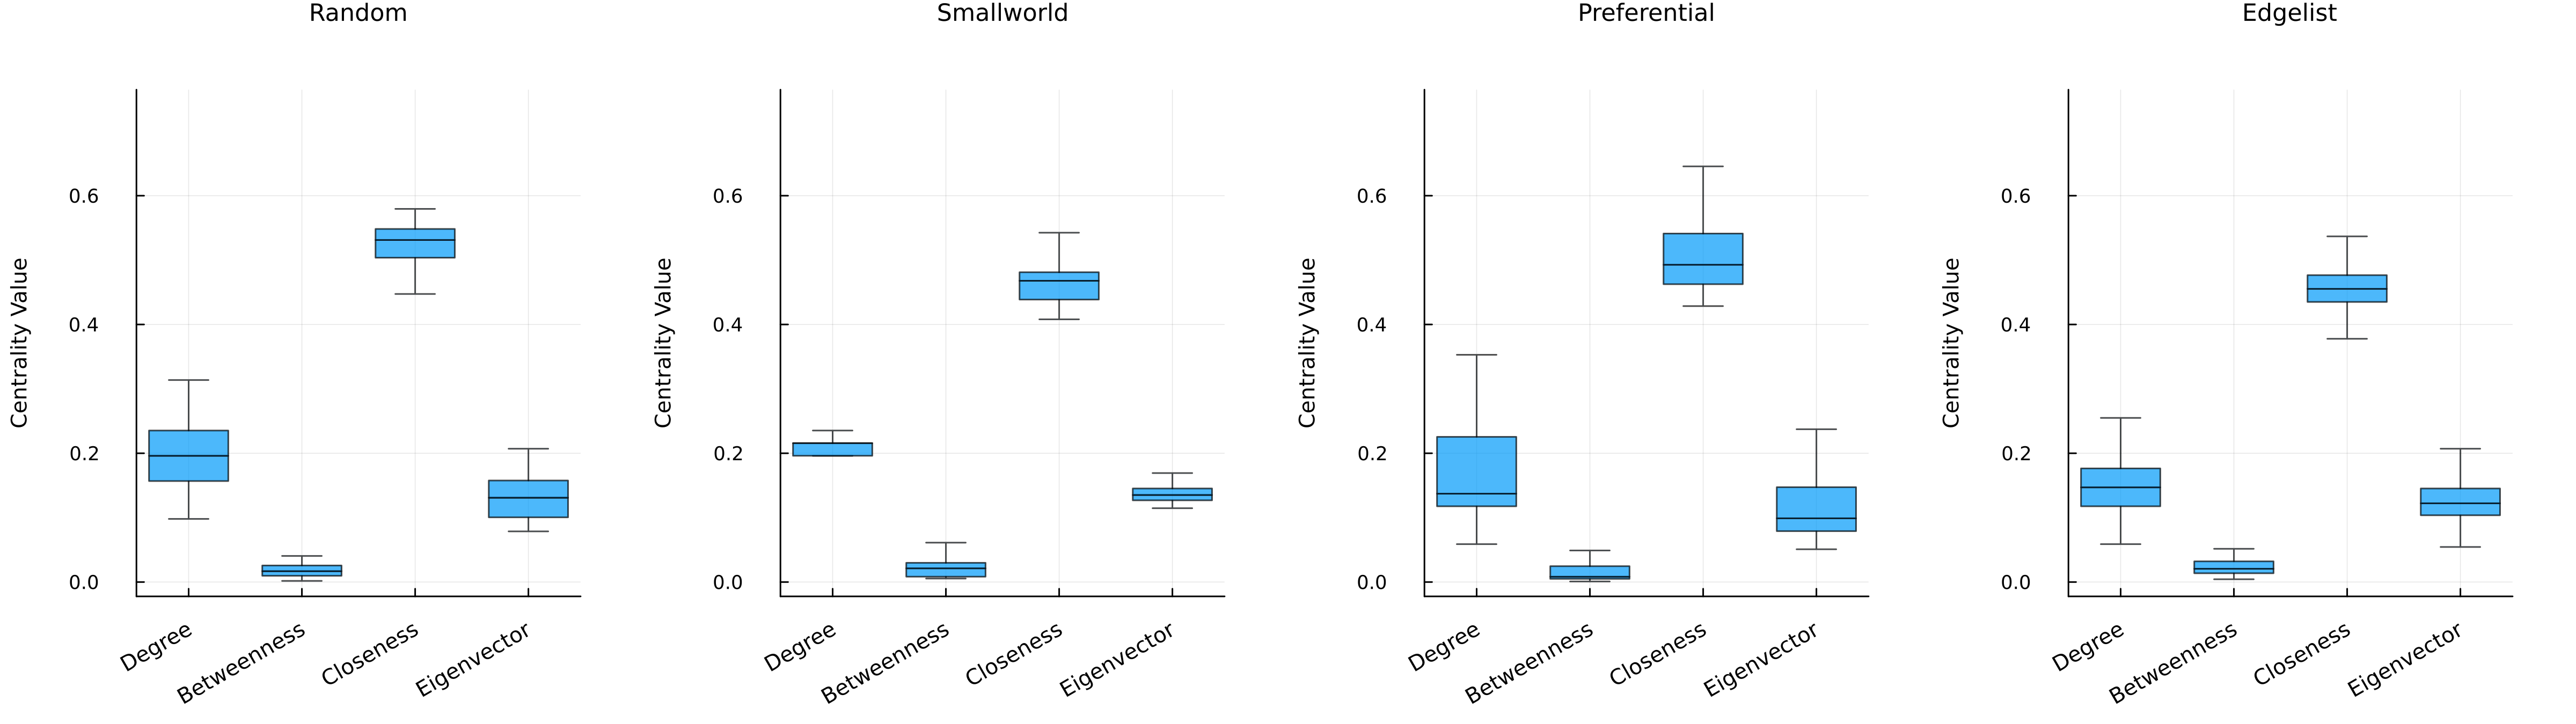

In [13]:
# Also generate centrality comparison for the same network types
println("\nGenerating centrality comparison for network structure analysis...")
centrality_comparison = plot_centrality_comparison(
    network_types = [:random, :smallworld, :preferential, :edgelist],
    mean_degree = model.mean_degree,
    n_nodes = model.n_nodes,
    link_axes = true
)

display(centrality_comparison)
println("Centrality comparison completed! Results saved to figures/ directory.")

## Epidemic Comparison

Now let's run multiple epidemic simulations to compare the dynamics across different network types. This will show how the network structure affects epidemic spread patterns.

Running epidemic comparison between network types...
This may take a few minutes as it runs multiple simulations...
Running simulations for random network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Running simulations for smallworld network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Running simulations for preferential network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Running simulations for edgelist network...
Saving simulation results to data/simulation_results...
Saving final results to output/final_results...
Saving combined comparison plot to figures/combined_comparison_mdeg_10.pdf
Epidemic comparison completed! Results saved to figures/ and output/ directories.


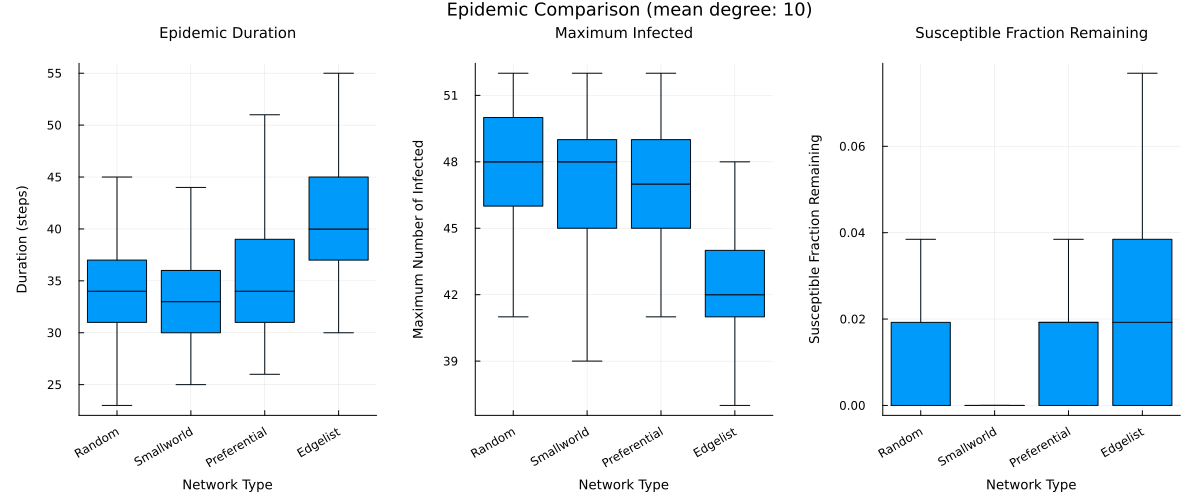

In [14]:
# Load the run_simulations function needed for epidemic comparison
include("src/run_simulations.jl")

# Run epidemic comparison across network types
println("Running epidemic comparison between network types...")
println("This may take a few minutes as it runs multiple simulations...")

# Note: Proportionate mixing networks may have issues with small network sizes
epidemic_comparison = run_and_plot_comparison(
    network_types = [:random, :smallworld, :preferential, :edgelist],
    mean_degree = model.mean_degree,
    n_nodes = model.n_nodes,
    trans_prob = 0.05,
    n_steps = 100
)

display(epidemic_comparison)
println("Epidemic comparison completed! Results saved to figures/ and output/ directories.")